# Benchmarking Notebook

Benchmarking **DFS** and **A*** on **Sudoku** and **Net** (pipes) puzzles at various sizes / difficulties.

## 1 · Setup

In [46]:
# Clone repo (skip if already cloned)
import os
if not os.path.isdir('IntroAiAssignment1'):
    !git clone git@github.com:namanhishere/IntroAiAssignment1.git

In [47]:
!pip install -q -r ./IntroAiAssignment1/requirements.txt
!pip install -q psutil py-cpuinfo matplotlib pandas tabulate

In [48]:
import sys, os
sys.path.insert(0, os.path.abspath("IntroAiAssignment1"))

In [49]:
from algorithms.dfs import DFS
from algorithms.astar import AStar
from domain import SudokuProblem, NetProblem
from generator.create_sodoku import generate_sudoku_puzzle
from generator.create_net import generate_net_puzzle

In [50]:
import random
import numpy as np
import time
import tracemalloc
import signal
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tabulate import tabulate

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## 2 · System Information

In [51]:
import platform, psutil
try:
    from cpuinfo import get_cpu_info
    cpu_name = get_cpu_info()['brand_raw']
except Exception:
    cpu_name = platform.processor()

print("-" * 40)
print("SYSTEM BENCHMARK METADATA")
print("-" * 40)
print(f"OS             : {platform.system()} {platform.release()} ({platform.architecture()[0]})")
print(f"Python Version : {platform.python_version()}")
print(f"CPU Model      : {cpu_name}")
print(f"Physical Cores : {psutil.cpu_count(logical=False)}")
print(f"Total Threads  : {psutil.cpu_count(logical=True)}")
cpufreq = psutil.cpu_freq()
if cpufreq:
    print(f"Max Frequency  : {cpufreq.max:.2f} MHz")
svmem = psutil.virtual_memory()
print(f"Total RAM      : {svmem.total / (1024**3):.2f} GB")
print("-" * 40)

----------------------------------------
SYSTEM BENCHMARK METADATA
----------------------------------------
OS             : Linux 6.17.0-14-generic (64bit)
Python Version : 3.12.3
CPU Model      : 12th Gen Intel(R) Core(TM) i7-12700H
Physical Cores : 14
Total Threads  : 20
Max Frequency  : 4180.00 MHz
Total RAM      : 38.87 GB
----------------------------------------


## 3 · Benchmark Helper

In [52]:
TIMEOUT = 120  # seconds per single run


class _Timeout(Exception):
    pass


def _alarm_handler(signum, frame):
    raise _Timeout()


def run_benchmark(algorithm, problem, timeout=TIMEOUT):
    """
    Run a single benchmark for *algorithm* on *problem*.

    Returns dict with:
        solved, time_s, steps, path_length, peak_memory_mb, timed_out
    """
    result_dict = {
        'solved': False,
        'time_s': None,
        'steps': None,
        'path_length': None,
        'peak_memory_mb': None,
        'timed_out': False,
    }

    old_handler = signal.signal(signal.SIGALRM, _alarm_handler)
    signal.alarm(timeout)

    tracemalloc.start()
    t0 = time.perf_counter()

    try:
        goal_node = algorithm.solve_benchmark(problem)
        t1 = time.perf_counter()
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        result_dict['time_s'] = round(t1 - t0, 4)
        result_dict['steps'] = algorithm.step_count
        result_dict['peak_memory_mb'] = round(peak / 1024 / 1024, 2)

        if goal_node is not None:
            result_dict['solved'] = True
            result_dict['path_length'] = len(goal_node.solution())

    except _Timeout:
        t1 = time.perf_counter()
        if tracemalloc.is_tracing():
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            result_dict['peak_memory_mb'] = round(peak / 1024 / 1024, 2)
        result_dict['timed_out'] = True
        result_dict['time_s'] = round(t1 - t0, 4)
        result_dict['steps'] = algorithm.step_count

    except Exception as e:
        t1 = time.perf_counter()
        if tracemalloc.is_tracing():
            tracemalloc.stop()
        result_dict['time_s'] = round(t1 - t0, 4)
        result_dict['error'] = str(e)

    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old_handler)

    return result_dict

### Algorithm Registry

In [53]:
ALGORITHMS = {
    'DFS': lambda: DFS(),
    'A*':  lambda: AStar(),   # uses problem.heuristic() automatically
}

---
## 4 · Sudoku Benchmark

### 4.1 Generate Sudoku Puzzles

Different difficulty = different number of cells removed.

In [54]:
SUDOKU_LEVELS = {
    'Easy (30)':   30,
    'Medium (40)': 40,
    'Hard (50)':   50,
    'Max':         'max',
}

NUM_SUDOKU_TRIALS = 3

sudoku_puzzles = {}  # level_name -> list[grid]

for level_name, level_val in SUDOKU_LEVELS.items():
    puzzles = []
    for trial in range(NUM_SUDOKU_TRIALS):
        seed = 1000 + trial
        grid = generate_sudoku_puzzle(seed=seed, level=level_val)
        clues = sum(1 for row in grid for c in row if c != 0)
        puzzles.append(grid)
        print(f"  {level_name} trial {trial}: {clues} clues")
    sudoku_puzzles[level_name] = puzzles
    print()

print("✅ Sudoku puzzle generation complete.")

--> Removed 30 cells.
  Easy (30) trial 0: 51 clues
--> Removed 30 cells.
  Easy (30) trial 1: 51 clues
--> Removed 30 cells.
  Easy (30) trial 2: 51 clues

--> Removed 40 cells.
  Medium (40) trial 0: 41 clues
--> Removed 40 cells.
  Medium (40) trial 1: 41 clues
--> Removed 40 cells.
  Medium (40) trial 2: 41 clues

--> Removed 50 cells.
  Hard (50) trial 0: 31 clues
--> Removed 50 cells.
  Hard (50) trial 1: 31 clues
--> Removed 50 cells.
  Hard (50) trial 2: 31 clues

--> Removed 57 cells.
  Max trial 0: 24 clues
--> Removed 55 cells.
  Max trial 1: 26 clues
--> Removed 57 cells.
  Max trial 2: 24 clues

✅ Sudoku puzzle generation complete.


### 4.2 Run Sudoku Benchmarks

In [55]:
sudoku_results = []

for level_name, puzzles in sudoku_puzzles.items():
    for trial_idx, grid in enumerate(puzzles):
        problem = SudokuProblem(grid)
        for algo_name, algo_factory in ALGORITHMS.items():
            algo = algo_factory()
            print(f"  {algo_name} | Sudoku {level_name} trial {trial_idx} ... ", end='', flush=True)
            res = run_benchmark(algo, problem)
            tag = '✅' if res['solved'] else ('⏱ TIMEOUT' if res.get('timed_out') else '❌')
            print(f"{tag}  time={res['time_s']}s  steps={res['steps']}")
            sudoku_results.append({
                'Game': 'Sudoku',
                'Difficulty': level_name,
                'Trial': trial_idx,
                'Algorithm': algo_name,
                **res,
            })

df_sudoku = pd.DataFrame(sudoku_results)
print("\n✅ Sudoku benchmarks complete.")

  DFS | Sudoku Easy (30) trial 0 ... ✅  time=0.0045s  steps=35
  A* | Sudoku Easy (30) trial 0 ... ✅  time=0.0052s  steps=42
  DFS | Sudoku Easy (30) trial 1 ... ✅  time=0.0041s  steps=36
  A* | Sudoku Easy (30) trial 1 ... ✅  time=0.0052s  steps=46
  DFS | Sudoku Easy (30) trial 2 ... ✅  time=0.0044s  steps=40
  A* | Sudoku Easy (30) trial 2 ... ✅  time=0.0053s  steps=44
  DFS | Sudoku Medium (40) trial 0 ... ✅  time=0.006s  steps=50
  A* | Sudoku Medium (40) trial 0 ... ✅  time=0.0071s  steps=58
  DFS | Sudoku Medium (40) trial 1 ... ✅  time=0.0101s  steps=87
  A* | Sudoku Medium (40) trial 1 ... ✅  time=0.0388s  steps=314
  DFS | Sudoku Medium (40) trial 2 ... ✅  time=0.0076s  steps=63
  A* | Sudoku Medium (40) trial 2 ... ✅  time=0.0153s  steps=118
  DFS | Sudoku Hard (50) trial 0 ... ✅  time=0.0409s  steps=357
  A* | Sudoku Hard (50) trial 0 ... ✅  time=0.0526s  steps=411
  DFS | Sudoku Hard (50) trial 1 ... ✅  time=0.6577s  steps=6250
  A* | Sudoku Hard (50) trial 1 ... ✅  time=3

### 4.3 Sudoku Results Table

In [56]:
sudoku_summary = df_sudoku.groupby(['Difficulty', 'Algorithm']).agg(
    Solved=('solved', 'sum'),
    Total=('solved', 'count'),
    Avg_Time_s=('time_s', 'mean'),
    Avg_Steps=('steps', 'mean'),
    Avg_Path_Length=('path_length', 'mean'),
    Avg_Peak_Memory_MB=('peak_memory_mb', 'mean'),
).reset_index()

sudoku_summary['Avg_Time_s'] = sudoku_summary['Avg_Time_s'].round(4)
sudoku_summary['Avg_Steps'] = sudoku_summary['Avg_Steps'].round(0).astype('Int64')
sudoku_summary['Avg_Path_Length'] = sudoku_summary['Avg_Path_Length'].round(1)
sudoku_summary['Avg_Peak_Memory_MB'] = sudoku_summary['Avg_Peak_Memory_MB'].round(2)

print("=" * 100)
print(f"SUDOKU BENCHMARK RESULTS  (averaged over {NUM_SUDOKU_TRIALS} trials)")
print("=" * 100)
print(tabulate(sudoku_summary, headers='keys', tablefmt='github', showindex=False))

SUDOKU BENCHMARK RESULTS  (averaged over 3 trials)
| Difficulty   | Algorithm   |   Solved |   Total |   Avg_Time_s |   Avg_Steps |   Avg_Path_Length |   Avg_Peak_Memory_MB |
|--------------|-------------|----------|---------|--------------|-------------|-------------------|----------------------|
| Easy (30)    | A*          |        3 |       3 |       0.0052 |          44 |              30   |                 0.07 |
| Easy (30)    | DFS         |        3 |       3 |       0.0043 |          37 |              30   |                 0.07 |
| Hard (50)    | A*          |        3 |       3 |       1.2178 |        9370 |              50   |                12.17 |
| Hard (50)    | DFS         |        3 |       3 |       0.2373 |        2245 |              50   |                 0.4  |
| Max          | A*          |        3 |       3 |      10.7901 |       81643 |              56.3 |               106.91 |
| Max          | DFS         |        3 |       3 |       2.9785 |       31077 | 

### 4.4 Sudoku Visualizations

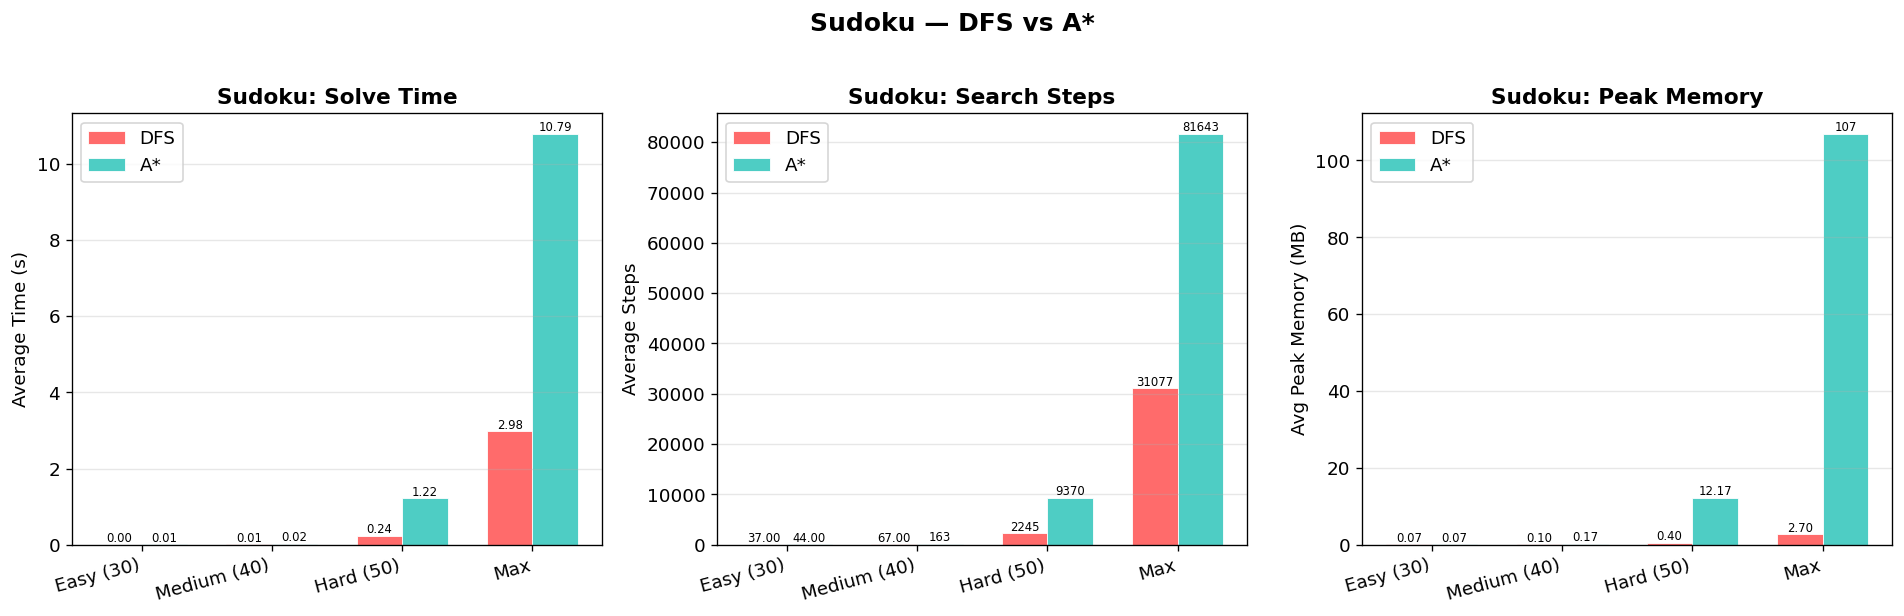

📊 Saved sudoku_benchmark.png


In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('Avg_Time_s',          'Average Time (s)',       'Sudoku: Solve Time'),
    ('Avg_Steps',           'Average Steps',          'Sudoku: Search Steps'),
    ('Avg_Peak_Memory_MB',  'Avg Peak Memory (MB)',   'Sudoku: Peak Memory'),
]

difficulties = list(SUDOKU_LEVELS.keys())
algo_names   = list(ALGORITHMS.keys())
colors       = {'DFS': '#FF6B6B', 'A*': '#4ECDC4'}
x            = np.arange(len(difficulties))
width        = 0.35

for ax, (col, ylabel, title) in zip(axes, metrics):
    for i, algo in enumerate(algo_names):
        vals = []
        for diff in difficulties:
            row = sudoku_summary[
                (sudoku_summary['Difficulty'] == diff) &
                (sudoku_summary['Algorithm'] == algo)
            ]
            v = row[col].values[0] if len(row) > 0 else 0
            vals.append(float(v) if pd.notna(v) else 0)
        offset = -width/2 + i * width
        bars = ax.bar(x + offset, vals, width, label=algo,
                      color=colors[algo], edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        f'{v:.2f}' if isinstance(v, float) and v < 100 else f'{v:.0f}',
                        ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(difficulties, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Sudoku — DFS vs A*', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sudoku_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved sudoku_benchmark.png")

---
## 5 · Net (Pipes) Benchmark

### 5.1 Generate Net Puzzles

We generate puzzles at different grid sizes.  
The generator supports different spanning-tree algorithms (`dfs`, `prim`, `kruskal`, `eller`).  
We use the default `dfs` tree generation for consistency.

In [67]:
NET_SIZES       = [30, 40, 50, 60, 70]
NUM_NET_TRIALS  = 5

net_puzzles = {}   # size -> list[grid]

for size in NET_SIZES:
    grids = []
    for trial in range(NUM_NET_TRIALS):
        seed = 3000 + size * 100 + trial
        grid = generate_net_puzzle(size=size, seed=seed, scramble=True)
        grids.append(grid)
        print(f"  Net {size}x{size} trial {trial}: generated (seed={seed})")
    net_puzzles[size] = grids
    print()

print("✅ Net puzzle generation complete.")

  Net 30x30 trial 0: generated (seed=6000)
  Net 30x30 trial 1: generated (seed=6001)
  Net 30x30 trial 2: generated (seed=6002)
  Net 30x30 trial 3: generated (seed=6003)
  Net 30x30 trial 4: generated (seed=6004)

  Net 40x40 trial 0: generated (seed=7000)
  Net 40x40 trial 1: generated (seed=7001)
  Net 40x40 trial 2: generated (seed=7002)
  Net 40x40 trial 3: generated (seed=7003)
  Net 40x40 trial 4: generated (seed=7004)

  Net 50x50 trial 0: generated (seed=8000)
  Net 50x50 trial 1: generated (seed=8001)
  Net 50x50 trial 2: generated (seed=8002)
  Net 50x50 trial 3: generated (seed=8003)
  Net 50x50 trial 4: generated (seed=8004)

  Net 60x60 trial 0: generated (seed=9000)
  Net 60x60 trial 1: generated (seed=9001)
  Net 60x60 trial 2: generated (seed=9002)
  Net 60x60 trial 3: generated (seed=9003)
  Net 60x60 trial 4: generated (seed=9004)

  Net 70x70 trial 0: generated (seed=10000)
  Net 70x70 trial 1: generated (seed=10001)
  Net 70x70 trial 2: generated (seed=10002)
  Ne

### 5.2 Run Net Benchmarks

In [68]:
net_results = []

for size, grids in net_puzzles.items():
    for trial_idx, grid in enumerate(grids):
        problem = NetProblem(grid)
        for algo_name, algo_factory in ALGORITHMS.items():
            algo = algo_factory()
            print(f"  {algo_name} | Net {size}x{size} trial {trial_idx} ... ", end='', flush=True)
            res = run_benchmark(algo, problem)
            tag = '✅' if res['solved'] else ('⏱ TIMEOUT' if res.get('timed_out') else '❌')
            print(f"{tag}  time={res['time_s']}s  steps={res['steps']}")
            net_results.append({
                'Game': 'Net',
                'Size': f"{size}x{size}",
                'SizeN': size,
                'Trial': trial_idx,
                'Algorithm': algo_name,
                **res,
            })

df_net = pd.DataFrame(net_results)
print("\n✅ Net benchmarks complete.")

  DFS | Net 30x30 trial 0 ... 

✅  time=0.2729s  steps=1549
  A* | Net 30x30 trial 0 ... ✅  time=0.3711s  steps=2007
  DFS | Net 30x30 trial 1 ... ✅  time=0.2337s  steps=1532
  A* | Net 30x30 trial 1 ... ✅  time=0.4084s  steps=2040
  DFS | Net 30x30 trial 2 ... ✅  time=0.1946s  steps=1264
  A* | Net 30x30 trial 2 ... ✅  time=0.2589s  steps=1641
  DFS | Net 30x30 trial 3 ... ✅  time=0.4298s  steps=3017
  A* | Net 30x30 trial 3 ... ✅  time=0.5579s  steps=3454
  DFS | Net 30x30 trial 4 ... ✅  time=0.3648s  steps=2287
  A* | Net 30x30 trial 4 ... ✅  time=0.5134s  steps=2368
  DFS | Net 40x40 trial 0 ... ✅  time=1.3928s  steps=5172
  A* | Net 40x40 trial 0 ... ✅  time=2.3326s  steps=7064
  DFS | Net 40x40 trial 1 ... ✅  time=0.7218s  steps=2830
  A* | Net 40x40 trial 1 ... ✅  time=0.9913s  steps=3497
  DFS | Net 40x40 trial 2 ... ✅  time=1.2037s  steps=4854
  A* | Net 40x40 trial 2 ... ✅  time=1.9565s  steps=6556
  DFS | Net 40x40 trial 3 ... ✅  time=1.191s  steps=4609
  A* | Net 40x40 trial 3 ... ✅  time=3.268s  steps=97

### 5.3 Net Results Table

In [69]:
net_summary = df_net.groupby(['Size', 'Algorithm']).agg(
    Solved=('solved', 'sum'),
    Total=('solved', 'count'),
    Avg_Time_s=('time_s', 'mean'),
    Avg_Steps=('steps', 'mean'),
    Avg_Path_Length=('path_length', 'mean'),
    Avg_Peak_Memory_MB=('peak_memory_mb', 'mean'),
).reset_index()

net_summary['Avg_Time_s'] = net_summary['Avg_Time_s'].round(4)
net_summary['Avg_Steps'] = net_summary['Avg_Steps'].round(0).astype('Int64')
net_summary['Avg_Path_Length'] = net_summary['Avg_Path_Length'].round(1)
net_summary['Avg_Peak_Memory_MB'] = net_summary['Avg_Peak_Memory_MB'].round(2)

print("=" * 100)
print(f"NET BENCHMARK RESULTS  (averaged over {NUM_NET_TRIALS} trials)")
print("=" * 100)
print(tabulate(net_summary, headers='keys', tablefmt='github', showindex=False))

NET BENCHMARK RESULTS  (averaged over 5 trials)
| Size   | Algorithm   |   Solved |   Total |   Avg_Time_s |   Avg_Steps |   Avg_Path_Length |   Avg_Peak_Memory_MB |
|--------|-------------|----------|---------|--------------|-------------|-------------------|----------------------|
| 30x30  | A*          |        5 |       5 |       0.4219 |        2302 |             898.4 |                28.93 |
| 30x30  | DFS         |        5 |       5 |       0.2992 |        1930 |             898.4 |                27.19 |
| 40x40  | A*          |        5 |       5 |       2.2163 |        7061 |            1597.4 |               113.13 |
| 40x40  | DFS         |        5 |       5 |       1.2134 |        4853 |            1597.4 |                86.48 |
| 50x50  | A*          |        5 |       5 |       5.7434 |       12153 |            2494.6 |               293.03 |
| 50x50  | DFS         |        5 |       5 |       3.6943 |        8637 |            2494.6 |               209.76 |
| 60x60 

### 5.4 Net Visualizations

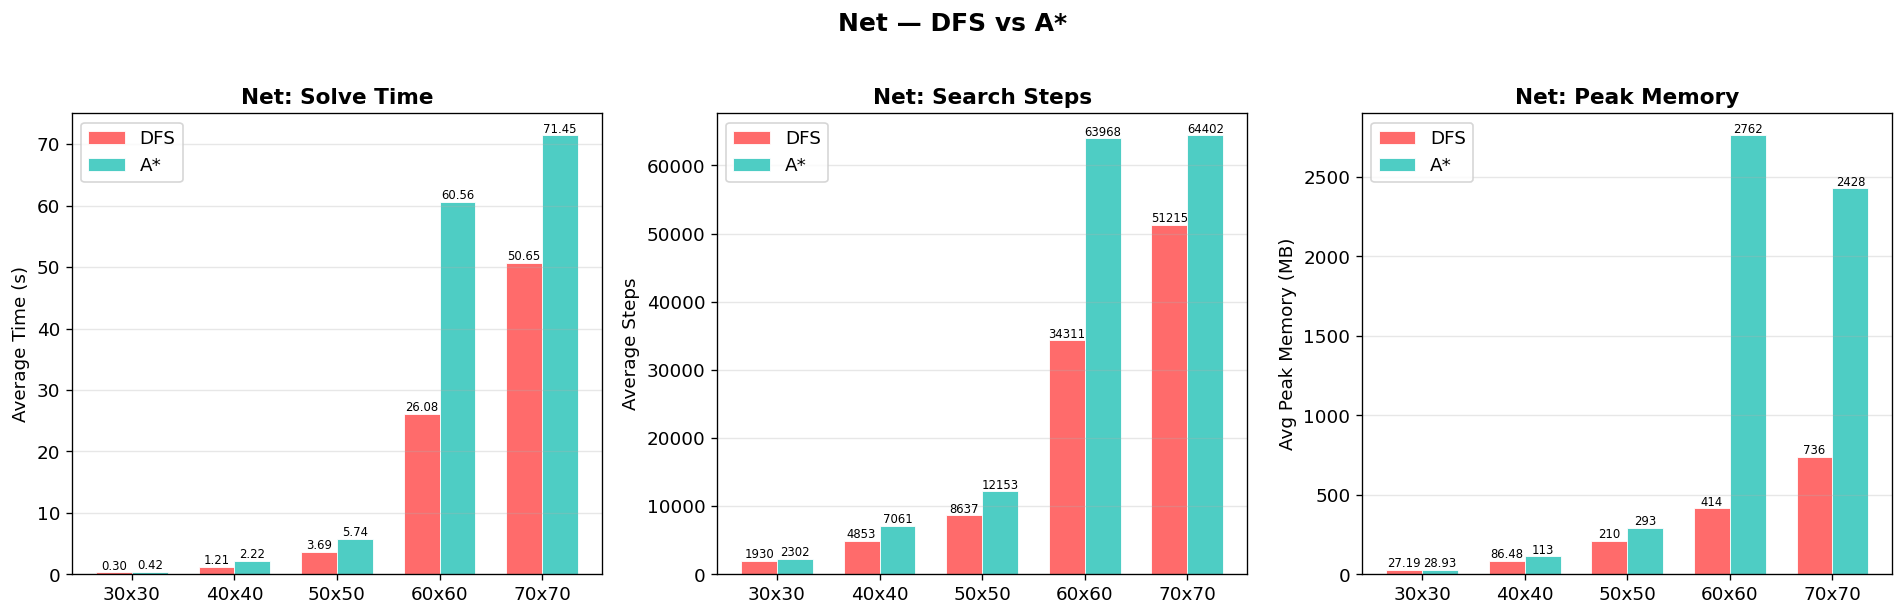

📊 Saved net_benchmark.png


In [70]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('Avg_Time_s',          'Average Time (s)',       'Net: Solve Time'),
    ('Avg_Steps',           'Average Steps',          'Net: Search Steps'),
    ('Avg_Peak_Memory_MB',  'Avg Peak Memory (MB)',   'Net: Peak Memory'),
]

sizes_labels = [f"{s}x{s}" for s in NET_SIZES]
x     = np.arange(len(NET_SIZES))
width = 0.35

for ax, (col, ylabel, title) in zip(axes, metrics):
    for i, algo in enumerate(algo_names):
        vals = []
        for s_label in sizes_labels:
            row = net_summary[
                (net_summary['Size'] == s_label) &
                (net_summary['Algorithm'] == algo)
            ]
            v = row[col].values[0] if len(row) > 0 else 0
            vals.append(float(v) if pd.notna(v) else 0)
        offset = -width/2 + i * width
        bars = ax.bar(x + offset, vals, width, label=algo,
                      color=colors[algo], edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        f'{v:.2f}' if v < 100 else f'{v:.0f}',
                        ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(sizes_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Net — DFS vs A*', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('net_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved net_benchmark.png")

---
## 6 · Combined Summary

In [62]:
df_all = pd.concat([df_sudoku, df_net], ignore_index=True)

df_all['Puzzle'] = df_all.apply(
    lambda r: f"Sudoku {r['Difficulty']}" if r['Game'] == 'Sudoku'
              else f"Net {r['Size']}",
    axis=1
)

combined = df_all.groupby(['Puzzle', 'Algorithm']).agg(
    Solved=('solved', 'sum'),
    Total=('solved', 'count'),
    Avg_Time_s=('time_s', 'mean'),
    Avg_Steps=('steps', 'mean'),
    Avg_Path_Length=('path_length', 'mean'),
    Avg_Peak_Memory_MB=('peak_memory_mb', 'mean'),
).reset_index()

combined['Avg_Time_s'] = combined['Avg_Time_s'].round(4)
combined['Avg_Steps'] = combined['Avg_Steps'].round(0).astype('Int64')
combined['Avg_Path_Length'] = combined['Avg_Path_Length'].round(1)
combined['Avg_Peak_Memory_MB'] = combined['Avg_Peak_Memory_MB'].round(2)

print("=" * 110)
print("COMBINED BENCHMARK RESULTS")
print("=" * 110)
print(tabulate(combined, headers='keys', tablefmt='github', showindex=False))

COMBINED BENCHMARK RESULTS
| Puzzle             | Algorithm   |   Solved |   Total |   Avg_Time_s |   Avg_Steps |   Avg_Path_Length |   Avg_Peak_Memory_MB |
|--------------------|-------------|----------|---------|--------------|-------------|-------------------|----------------------|
| Net 3x3            | A*          |        3 |       3 |       0.0005 |          14 |               9   |                 0.01 |
| Net 3x3            | DFS         |        3 |       3 |       0.0005 |          12 |               9   |                 0.01 |
| Net 4x4            | A*          |        3 |       3 |       0.0008 |          20 |              16   |                 0.02 |
| Net 4x4            | DFS         |        3 |       3 |       0.0008 |          18 |              16   |                 0.02 |
| Net 5x5            | A*          |        3 |       3 |       0.0014 |          31 |              25   |                 0.05 |
| Net 5x5            | DFS         |        3 |       3 |      

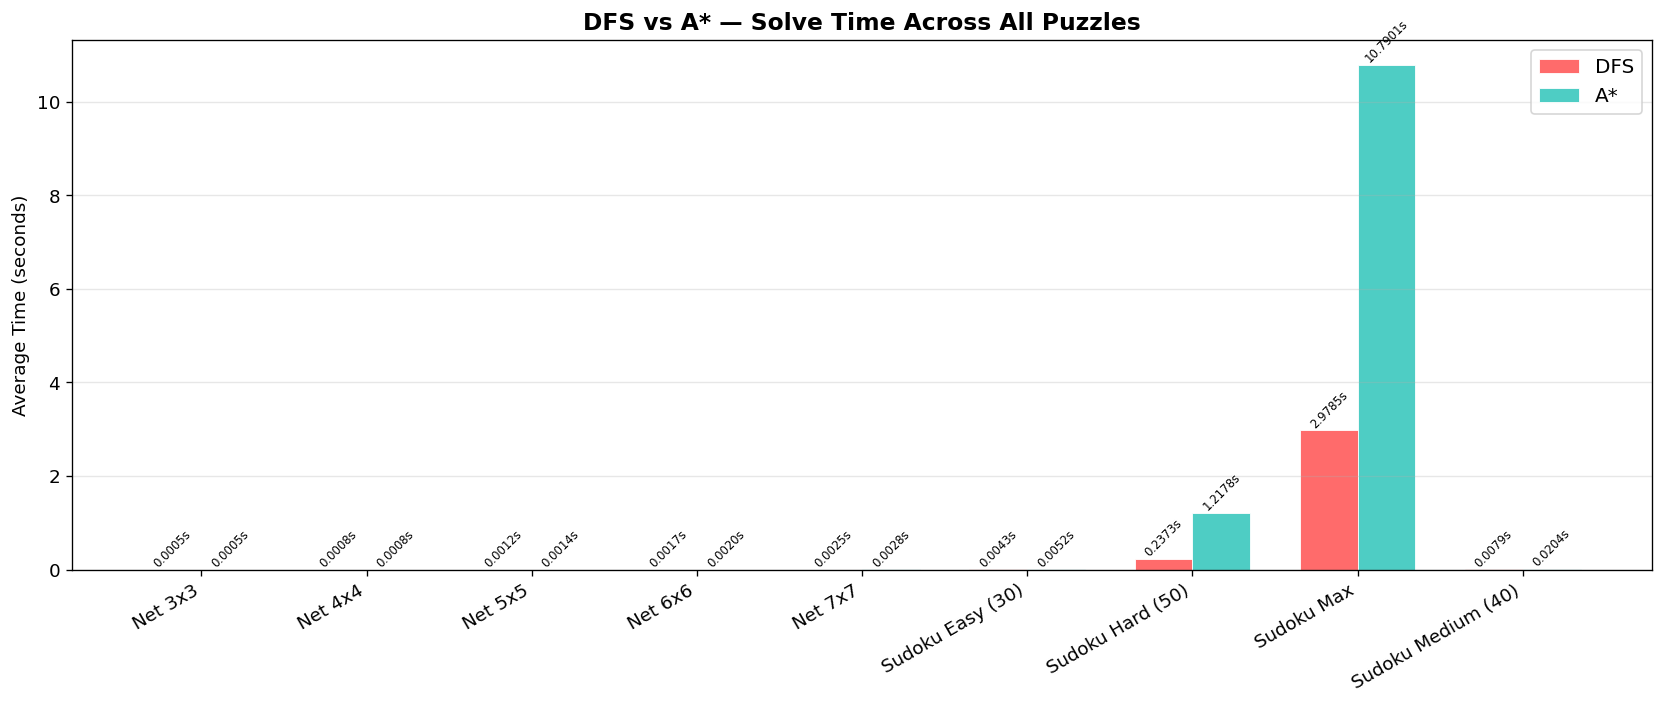

📊 Saved combined_benchmark.png


In [63]:
fig, ax = plt.subplots(figsize=(14, 6))

puzzle_labels = combined['Puzzle'].unique()
x     = np.arange(len(puzzle_labels))
width = 0.35

for i, algo in enumerate(algo_names):
    vals = []
    for p in puzzle_labels:
        row = combined[
            (combined['Puzzle'] == p) &
            (combined['Algorithm'] == algo)
        ]
        v = row['Avg_Time_s'].values[0] if len(row) > 0 else 0
        vals.append(float(v) if pd.notna(v) else 0)
    offset = -width/2 + i * width
    bars = ax.bar(x + offset, vals, width, label=algo,
                  color=colors[algo], edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{v:.4f}s', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(puzzle_labels, rotation=30, ha='right')
ax.set_ylabel('Average Time (seconds)')
ax.set_title('DFS vs A* — Solve Time Across All Puzzles', fontweight='bold', fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('combined_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved combined_benchmark.png")

## 7 · Raw Results (all trials)

In [64]:
print("\n" + "=" * 90)
print("ALL SUDOKU TRIALS")
print("=" * 90)
cols = ['Difficulty','Trial','Algorithm','solved','time_s','steps','path_length','peak_memory_mb']
print(tabulate(df_sudoku[cols], headers='keys', tablefmt='github', showindex=False))

print("\n" + "=" * 90)
print("ALL NET TRIALS")
print("=" * 90)
cols = ['Size','Trial','Algorithm','solved','time_s','steps','path_length','peak_memory_mb']
print(tabulate(df_net[cols], headers='keys', tablefmt='github', showindex=False))


ALL SUDOKU TRIALS
| Difficulty   |   Trial | Algorithm   | solved   |   time_s |   steps |   path_length |   peak_memory_mb |
|--------------|---------|-------------|----------|----------|---------|---------------|------------------|
| Easy (30)    |       0 | DFS         | True     |   0.0045 |      35 |            30 |             0.07 |
| Easy (30)    |       0 | A*          | True     |   0.0052 |      42 |            30 |             0.07 |
| Easy (30)    |       1 | DFS         | True     |   0.0041 |      36 |            30 |             0.07 |
| Easy (30)    |       1 | A*          | True     |   0.0052 |      46 |            30 |             0.07 |
| Easy (30)    |       2 | DFS         | True     |   0.0044 |      40 |            30 |             0.07 |
| Easy (30)    |       2 | A*          | True     |   0.0053 |      44 |            30 |             0.07 |
| Medium (40)  |       0 | DFS         | True     |   0.006  |      50 |            40 |             0.09 |
| Medium 

In [65]:
df_all.to_csv('benchmark_results.csv', index=False)
print("💾 Full results saved to benchmark_results.csv")

💾 Full results saved to benchmark_results.csv
